# **Leitura Inicial da Base de Dados**

Instalação das bibliotecas

Caso alguma biblioteca não esteja instalada, execute:

In [ ]:
pip install pandas numpy matplotlib seaborn plotly

Bibliotecas Utilizadas
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Visualização e leitura inicial
---

In [ ]:
df = pd.read_csv('../data/bronze.csv')

display(df.head(15))

,rating_agency,corporation,rating,rating_date,cik,binary_rating,sic_code,sector_x,ticker,current_ratio,...,sdg_life_on_land,"sdg_peace,_justice_and_strong_institutions",sdg_partnerships_for_the_goals,esg,involvement_msci_controversial_weapons,involvement_msci_gambling,involvement_msci_tobacco_products,involvement_msci_alcoholic_beverages,involvement,involvement_msci
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,1056903,1,4941.0,Utils,AWR,1.1507,...,NaN,NaN,NaN,32.5,No,No,No,No,No,No
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,8670,1,7374.0,BusEq,ADP,1.1129,...,No,Aligned,No,NaN,No,No,No,No,No,No
2,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,8670,1,7374.0,BusEq,ADP,1.1129,...,No,Aligned,Aligned,NaN,No,No,Yes,Yes,No,No
3,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,8858,1,5065.0,Shops,AVT,1.9276,...,NaN,NaN,NaN,NaN,No,No,No,No,No,No
4,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,1035201,1,4941.0,Utils,CWT,0.8358,...,NaN,NaN,NaN,30.1,No,No,No,No,No,No
5,Standard & Poor's Ratings Services,Carpenter Technology Corp.,BBB,2010-12-20,17843,1,3312.0,Manuf,CRS,3.7607,...,NaN,NaN,NaN,NaN,No,No,No,No,No,No
6,Standard & Poor's Ratings Services,Companhia de Saneamento Basico do Estado de Sa...,BB,2010-12-07,1170858,0,4941.0,Utils,SBS,0.8134,...,NaN,NaN,NaN,NaN,No,No,No,No,No,No
7,Standard & Poor's Ratings Services,Companhia de Saneamento Basico do Estado de Sa...,BB,2010-12-07,1170858,0,4941.0,Utils,SBS,0.8134,...,NaN,NaN,NaN,NaN,No,No,No,No,No,No
8,Standard & Poor's Ratings Services,Diageo PLC,A-,2010-10-01,835403,1,2085.0,NoDur,DEO,1.7627,...,NaN,NaN,NaN,NaN,No,No,No,No,No,No
9,Standard & Poor's Ratings Services,Entergy Corp,BBB-,2010-09-15,65984,1,4911.0,Utils,ETR,1.4196,...,No,No,No,26.1,No,No,No,No,No,No


Tipos de Variáveis
---

In [ ]:
for coluna in df.columns:
    print(f"Valores únicos na coluna '{coluna}':")
    print(df[coluna].unique())
    print("-" * 30)

Valores únicos na coluna 'rating_agency':
["Standard & Poor's Ratings Services" 'DBRS' "Moody's Investors Service"
 'Fitch Ratings' 'Japan Credit Rating Agency,Ltd.'
 'Egan-Jones Ratings Company']
------------------------------
Valores únicos na coluna 'corporation':
['American States Water Co.' 'Automatic Data Processing Inc.' 'Avnet Inc.'
 ... 'Thermo Fisher Scientific (Finance I) B.V.' 'Westlake Chemical Corp.'
 'Xerox Corp.']
------------------------------
Valores únicos na coluna 'rating':
['A-' 'AAA' 'BBB-' 'AA-' 'BBB' 'BB' 'A' 'B' 'BBB+' 'BB+' 'B+' 'BB-' 'B-'
 'A+' 'CCC' 'AA' 'CCC+' 'CC' 'CCC-' 'AA+' 'C' 'D' 'CC+']
------------------------------
Valores únicos na coluna 'rating_date':
['2010-07-30' '2010-09-16' '2010-11-23' ... '2016-09-01' '2016-01-19'
 '2016-03-02']
------------------------------
Valores únicos na coluna 'cik':
[1056903    8670    8858 1035201   17843 1170858  835403   65984 1135152
 1048911   30625 1124198 1047340   40704  898293   55242  885639 1315257
  887

In [ ]:
print("Tipos de Variáveis")
resumo_tipos = df.dtypes.value_counts()
for tipo, quantidade in resumo_tipos.items():
    print(f"Tipo {tipo}: {quantidade} coluna(s)")

Tipos de Variáveis
Tipo object: 55 coluna(s)
Tipo float64: 23 coluna(s)
Tipo int64: 2 coluna(s)


---

Dimensão da Base
---

In [ ]:
qtd_linhas, qtd_colunas = df.shape
print(f"Linhas (Instâncias): {qtd_linhas}")
print(f"Colunas (Atributos): {qtd_colunas}")

Linhas (Instâncias): 8667
Colunas (Atributos): 80


Valores Ausentes
---

In [ ]:
nulos = df.isnull().sum()
colunas_com_nulos = nulos[nulos > 0]

if colunas_com_nulos.empty:
    print("Não há valores ausentes na base de dados.\n")
else:
    print("Colunas que apresentam valores ausentes:")
    df_nulos = colunas_com_nulos.reset_index()
    df_nulos.columns = ['Nome da Coluna', 'Quantidade de Nulos']
    print(df_nulos)

Colunas que apresentam valores ausentes:
                                       Nome da Coluna  Quantidade de Nulos
0                                           employees                  175
1                                        altman_score                 1065
2                                     piotroski_score                  951
3                           controversies_environment                  936
4                                controversies_social                  936
5                             controversies_customers                  936
6            controversies_human_rights_and_community                  936
7         controversies_labor_rights_and_supply_chain                  936
8                            controversies_governance                  936
9                  decarbonization_target_target_year                 1302
10           decarbonization_target_comprehensiveness                 1302
11                decarbonization_target_ambition_p_a      

---

Registros Duplicados
---

In [ ]:
print("Número de duplicatas:", df.duplicated(subset=["name", "domain", "employees", "long_term_debt_per_capital",
"debtperequity_ratio", "gross_margin","operating_margin","ebit_margin"]).sum())

Número de duplicatas: 5833


# **Estatísticas Descritivas**

In [ ]:
colunas_numericas = df.select_dtypes(include=['number'])

estatisticas = colunas_numericas.describe().round(2)

estatisticas.loc['variância'] = colunas_numericas.var().round(2)
estatisticas.loc['assimetria'] = colunas_numericas.skew().round(2)

print("Estatísticas Descritivas:")
display(estatisticas.T)

Estatísticas Descritivas:


,count,mean,std,min,25%,50%,75%,max,variância,assimetria
cik,8667.0,725045.84,513228.84,1750.00,92380.00,875045.00,1069258.00,1748790.00,2.634038e+11,-0.15
binary_rating,8667.0,0.71,0.45,0.00,0.00,1.00,1.00,1.00,2.100000e-01,-0.93
sic_code,8667.0,4289.06,1901.28,100.00,2851.00,3812.00,5140.00,9997.00,3.614879e+06,0.44
current_ratio,8667.0,1.88,1.76,0.21,1.09,1.49,2.18,34.08,3.090000e+00,8.12
long_term_debt_per_capital,8667.0,0.43,0.30,-7.44,0.26,0.41,0.53,9.96,9.000000e-02,4.67
debtperequity_ratio,8667.0,1.20,9.18,-312.71,0.40,0.74,1.21,194.38,8.428000e+01,-6.58
gross_margin,8667.0,42.82,23.04,-87.68,24.87,39.65,60.15,100.00,5.307800e+02,0.31
operating_margin,8667.0,13.20,16.40,-324.12,6.76,12.66,19.88,63.20,2.689600e+02,-5.63
ebit_margin,8667.0,13.25,16.42,-324.12,6.90,12.67,19.91,63.20,2.695800e+02,-5.61
ebitda_margin,8667.0,20.99,17.80,-306.98,11.58,18.62,30.61,286.49,3.168000e+02,-2.18


# **Análise Exploratória e Identificação de Padrões e Problemas**

### **Visualização 1: Distribuição das Classes (Variável Alvo)**
Objetivo: Avaliar o balanceamento das categorias da variável alvo 'rating' no dataset.
---

Distribuição das Classes


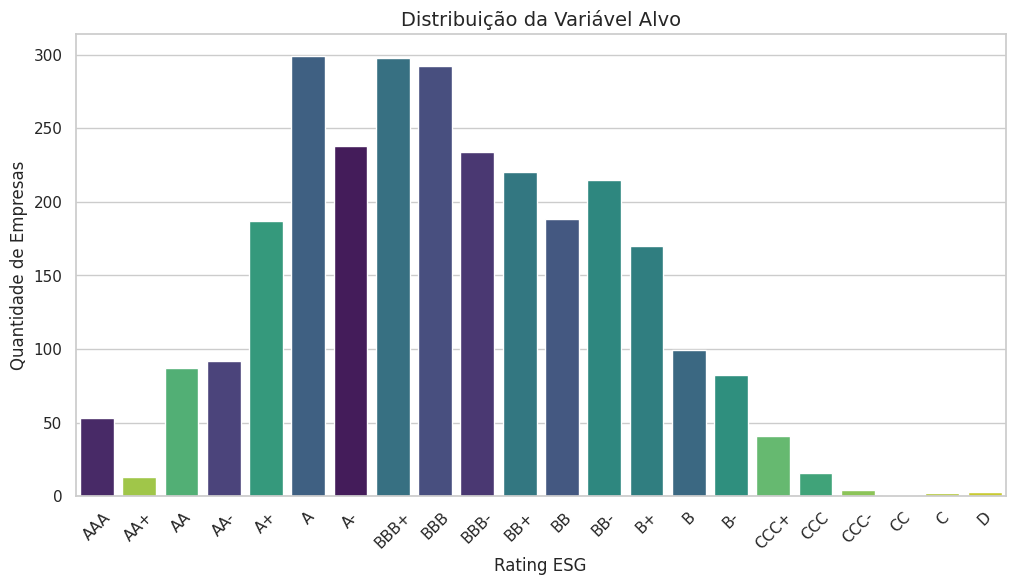

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Distribuição das Classes")
plt.figure(figsize=(12, 6))

escala_rating = [
    'AAA', 'AA+', 'AA', 'AA-', 'A+', 'A', 'A-',
    'BBB+', 'BBB', 'BBB-', 'BB+', 'BB', 'BB-',
    'B+', 'B', 'B-', 'CCC+', 'CCC', 'CCC-',
    'CC', 'C', 'D'
]

ordem_ratings = [nota for nota in escala_rating if nota in df['rating'].dropna().unique()]

sns.countplot(
    data=df,
    x='rating',
    hue='rating',
    order=ordem_ratings,
    palette='viridis',
    legend=False
)

plt.title('Distribuição da Variável Alvo', fontsize=14)
plt.ylabel('Quantidade de Empresas')
plt.xlabel('Rating ESG')
plt.xticks(rotation=45)
plt.show()

### **Visualização 2: Matriz de Correlação Linear**
Objetivo: Identificar relacionamentos lineares e problemas de multicolinearidade entre as
principais features
---

Matriz de Correlação


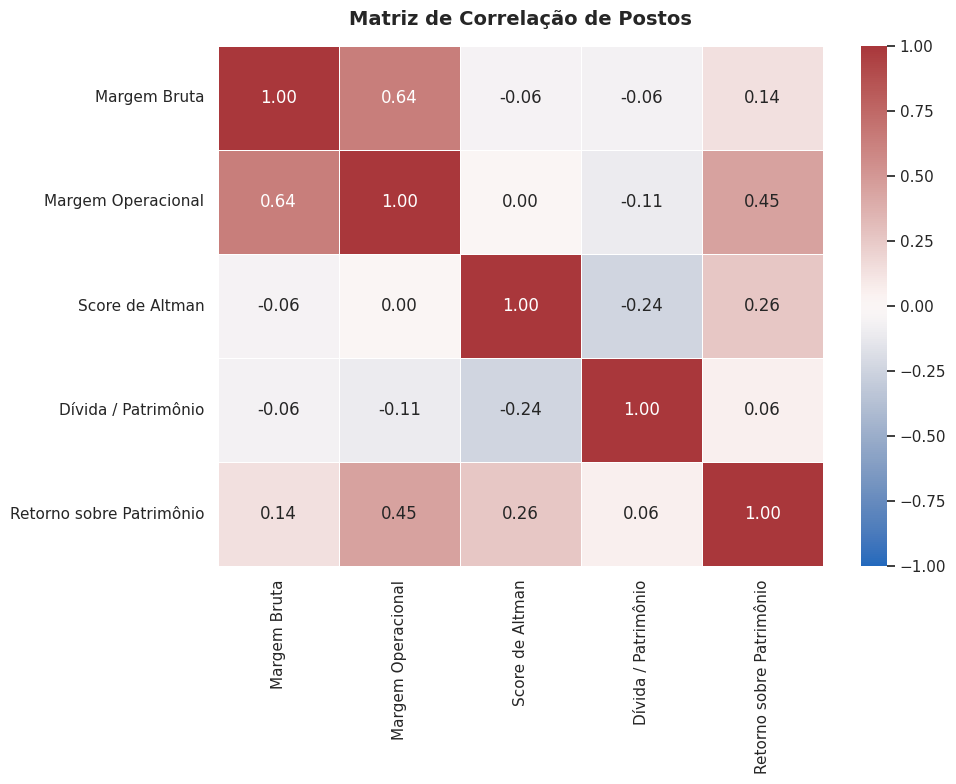

In [ ]:
print("Matriz de Correlação")

colunas_corr = [
    'gross_margin',
    'operating_margin',
    'altman_score',
    'debtperequity_ratio',
    'roe_return_on_equity'
]

traducoes = {
    'gross_margin': 'Margem Bruta',
    'operating_margin': 'Margem Operacional',
    'altman_score': 'Score de Altman',
    'debtperequity_ratio': 'Dívida / Patrimônio',
    'roe_return_on_equity': 'Retorno sobre Patrimônio'
}

matriz_corr_spearman = df[colunas_corr].rename(columns=traducoes).corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr_spearman,
            annot=True,
            cmap='vlag',
            fmt=".2f",
            linewidths=0.5,
            vmin=-1,
            vmax=1)

plt.title('Matriz de Correlação de Postos', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### **Visualização 3: Análise de Outliers e Dispersão (Boxplot)**
Objetivo: Visualizar a dispersão e a presença de outliers na métrica de alavancagem financeira (debtperequity_ratio) segmentada por categorias de Rating ESG.
---

Análise de Outliers (Boxplot)


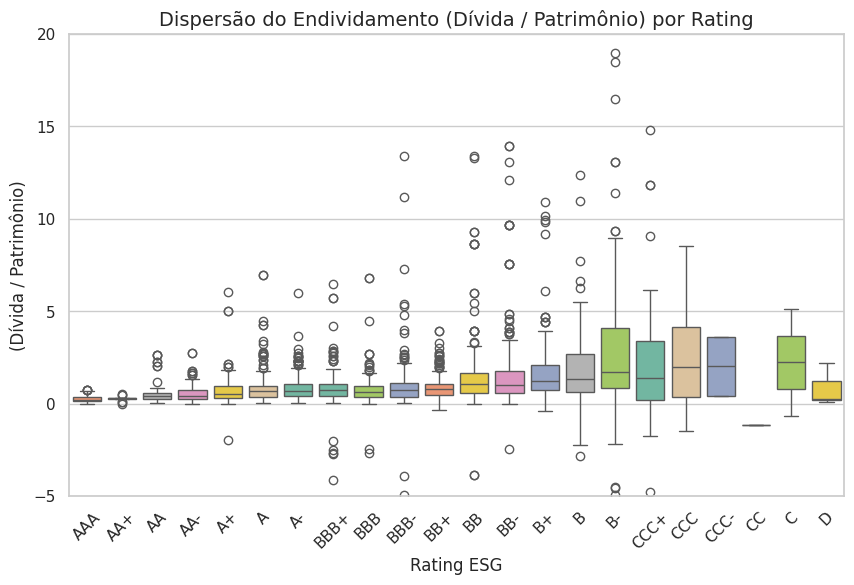

In [ ]:
print("Análise de Outliers (Boxplot)")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='rating', y='debtperequity_ratio', hue='rating', order=ordem_ratings, palette='Set2', legend=False)
plt.title('Dispersão do Endividamento (Dívida / Patrimônio) por Rating', fontsize=14)
plt.ylabel('(Dívida / Patrimônio)')
plt.xlabel('Rating ESG')
plt.xticks(rotation=45)
plt.ylim(-5, 20)
plt.show()

### **Visualização 4: Relações Multidimensionais entre Indicadores Financeiros (Pairplot)**
Analisar simultaneamente as distribuições individuais e os cruzamentos bivariados (correlações visuais) entre a saúde financeira (altman_score), a eficiência operacional (gross_margin) e o nível de endividamento (debtperequity_ratio), utilizando o rating ESG como fator de agrupamento por cores.
---

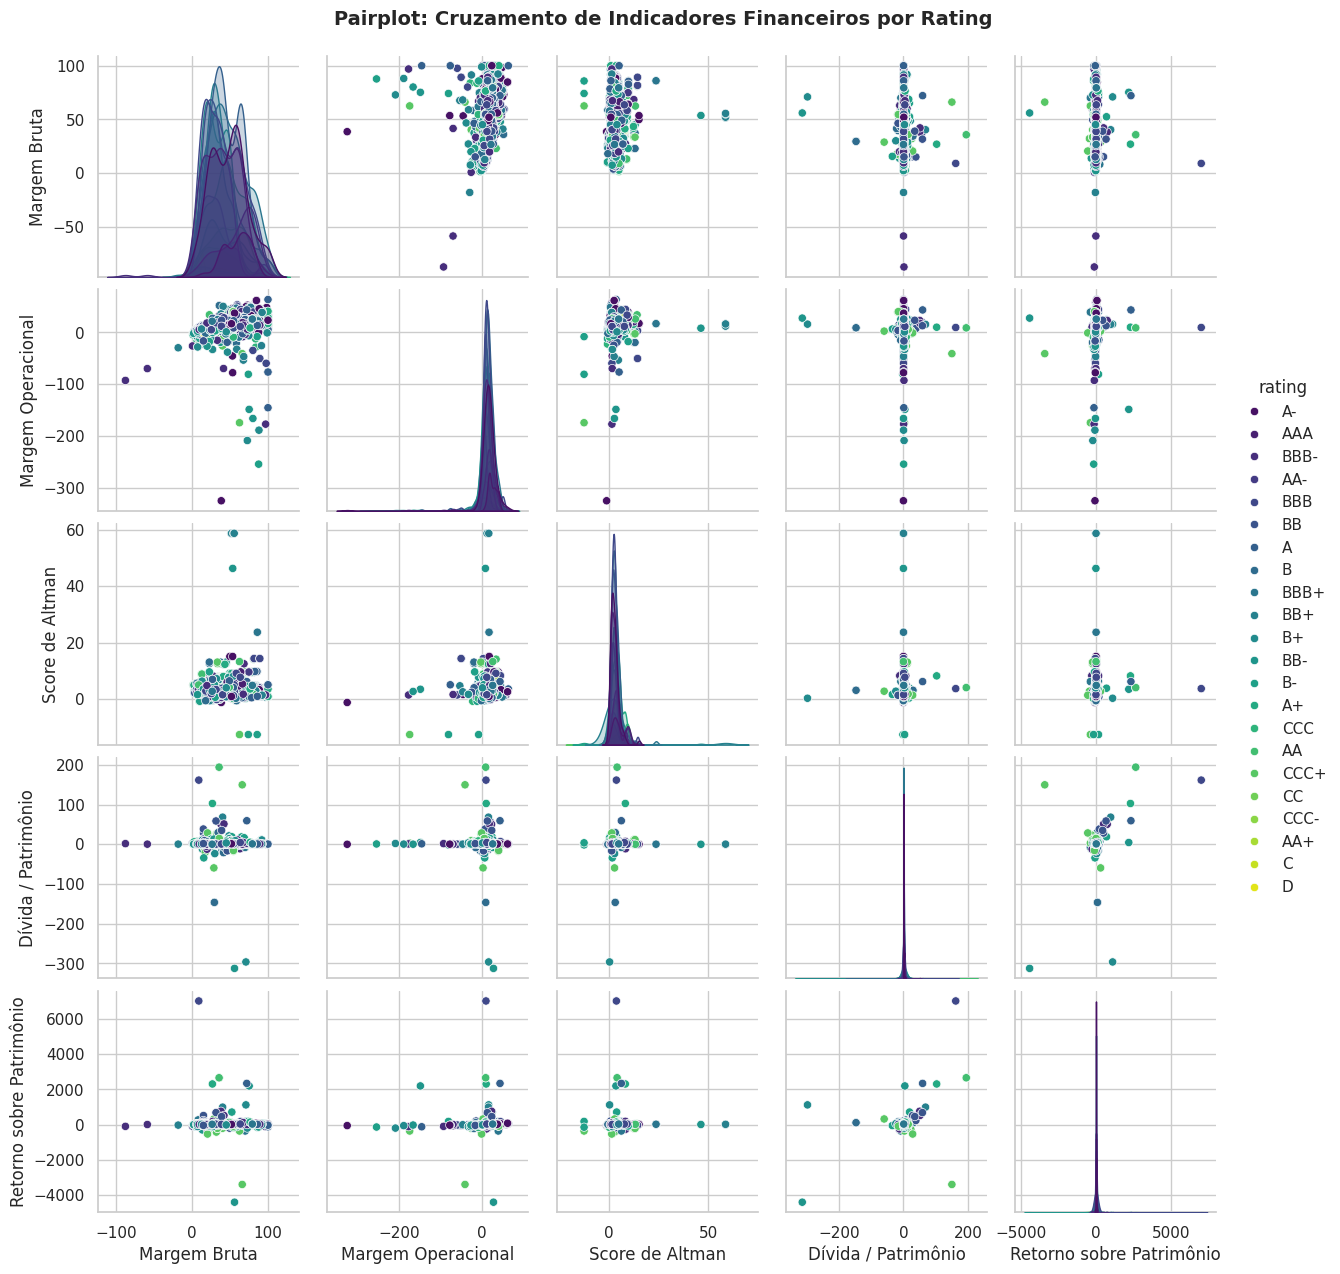

In [ ]:
colunas_pairplot = colunas_corr + ['rating']

sns.pairplot(df[colunas_pairplot].rename(columns=traducoes),
             hue='rating',
             palette='viridis',
             diag_kind='kde')
plt.suptitle('Pairplot: Cruzamento de Indicadores Financeiros por Rating', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### **Visualização 5: Gráfico de Dispersão**

Analisar a relação direta e a distribuição entre a lucratividade operacional (ebitda_margin) e a eficiência na alocação de ativos (roa_return_on_assets), utilizando a classificação da empresa (rating) como fator de agrupamento por cores para identificar padrões, concentrações de performance ou discrepâncias (outliers) entre os diferentes níveis de avaliação.
---

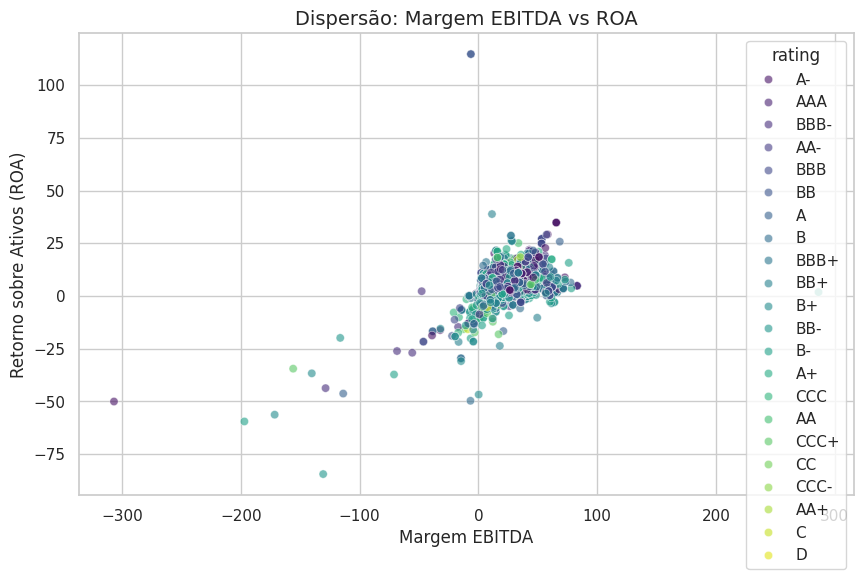

In [ ]:
sns.scatterplot(
    data=df,
    x='ebitda_margin',
    y='roa_return_on_assets',
    hue='rating',
    palette='viridis',
    alpha=0.6
)

plt.title('Dispersão: Margem EBITDA vs ROA', fontsize=14)
plt.xlabel('Margem EBITDA')
plt.ylabel('Retorno sobre Ativos (ROA)')

plt.show()

### **Visualização 6: Controvérsias por Ranking**

Avaliar a distribuição do volume de controvérsias (ambientais, sociais e de governança) nas diferentes faixas de classificação (rating). O objetivo é evidenciar inconsistências e identificar potenciais práticas de *greenwashing* — detectando anomalias onde empresas com notas elevadas de sustentabilidade apresentam, paradoxalmente, um alto histórico de violações e incidentes na prática.
---

Controvérsias por Ranking (Identificação de Greenwashing)


/tmp/ipykernel_7647/794207796.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




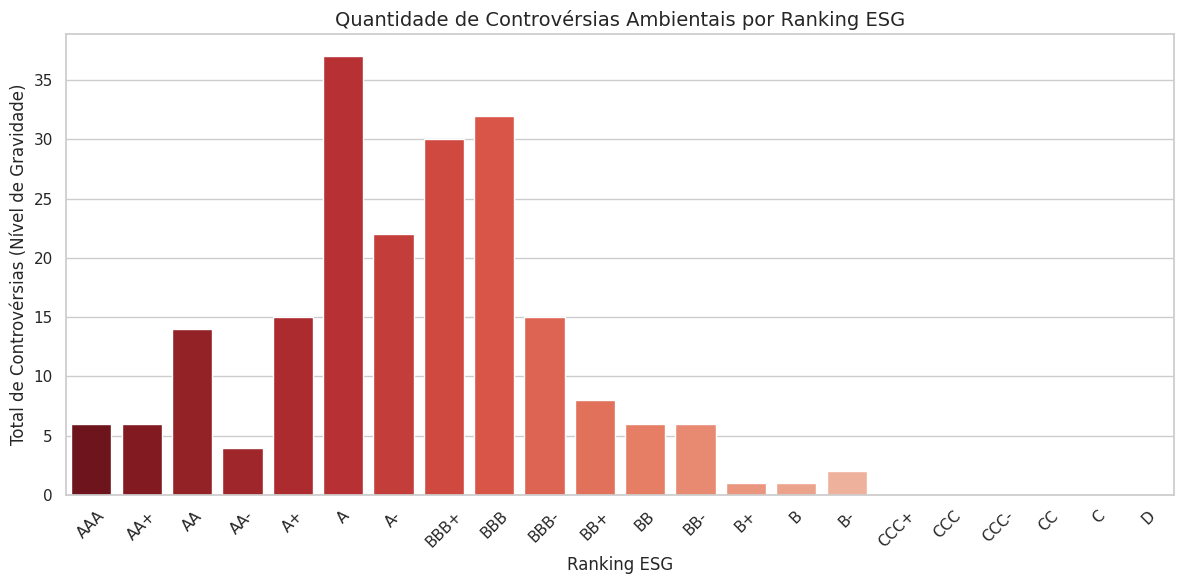

In [ ]:
print("Controvérsias por Ranking (Identificação de Greenwashing)")
agrupamento_rating = df_greenwashing.groupby('rating', observed=True)['qtd_controversias'].sum().reset_index()

escala_rating = ['AAA', 'AA+', 'AA', 'AA-', 'A+', 'A', 'A-', 'BBB+', 'BBB', 'BBB-', 'BB+', 'BB', 'BB-', 'B+', 'B', 'B-', 'CCC+', 'CCC', 'CCC-', 'CC', 'C', 'D']
agrupamento_rating['rating'] = pd.Categorical(agrupamento_rating['rating'], categories=escala_rating, ordered=True)
agrupamento_rating = agrupamento_rating.sort_values('rating')

plt.figure(figsize=(12, 6))
sns.barplot(data=agrupamento_rating, x='rating', y='qtd_controversias', palette='Reds_r', legend=False)
plt.title('Quantidade de Controvérsias Ambientais por Ranking ESG', fontsize=14)
plt.xlabel('Ranking ESG')
plt.ylabel('Total de Controvérsias (Nível de Gravidade)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()